In [1]:
!git clone https://github.com/A-Ariyanto/ml-side-project.git

Cloning into 'ml-side-project'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 0), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1.19 MiB | 4.55 MiB/s, done.


# Introduction

Written by Abdullah Ariyanto (z5543164). This notebook documents the development of a dual-task machine learning pipeline using vehicle insurance data.

## Project Objectives
The goal of this project is to develop a predictive pipeline for vehicle insurance data.
* **Task 1 (Regression):** Predict `safety_rating` (Target: $RMSE \le 1$).
* **Task 2 (Classification):** Predict `claim` (Target: $F1 \ge 0.60$).

## Technical Constraints
* **Runtime:** Total execution must be $\le 2$ minutes on CSE servers.
* **Environment:** Python 3.13 using only approved libraries
* **Data Integrity:** No merging of train/test sets and no target leakage.

## 1. Data Exploration, Cleaning & Preparation
First, we will load the dataset and perform an initial inspection to understand its structure, identify missing values, and observe the distributions of our target variables.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better readability
sns.set_theme(style="whitegrid")

In [4]:
# Load the training dataset
train_df = pd.read_csv('train.csv')

# Display basic information and the first few rows
display(train_df.info())
display(train_df.head())

# Check for missing values across all features
missing_values = train_df.isnull().sum()
display(missing_values[missing_values > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40194 entries, 0 to 40193
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   policy_id           40194 non-null  object 
 1   vehicle_usage_type  40194 non-null  object 
 2   cylinder            40194 non-null  int64  
 3   gross_weight        40194 non-null  int64  
 4   gear_box            40194 non-null  int64  
 5   fuel                40194 non-null  object 
 6   torque              40194 non-null  object 
 7   car_color           40194 non-null  object 
 8   features            40194 non-null  object 
 9   airbags             40194 non-null  int64  
 10  policy_age_months   40194 non-null  int64  
 11  population_density  40194 non-null  int64  
 12  transmission_type   40194 non-null  object 
 13  manufacturer        40194 non-null  int64  
 14  rear_brakes         40194 non-null  object 
 15  engine_type         40194 non-null  object 
 16  heig

None

,policy_id,vehicle_usage_type,cylinder,gross_weight,gear_box,fuel,torque,car_color,features,airbags,...,steering_type,driver_occupation,length,car_model,power,displacement,turning_radius,car_segment,safety_rating,claim
0,P1,Rental,3,1155,5,Petrol,91Nm@4250rpm,White,"['parking_camera', 'power_door_locks', 'centra...",2,...,Electric,Professional,3731,M3,67.06bhp@5500rpm,999,5.0,A,23,0
1,P2,Work and Personal,4,1720,6,Diesel,250Nm@2750rpm,Black,"['esc', 'adjustable_steering', 'tpms', 'parkin...",6,...,Power,Student,4300,M4,113.45bhp@4000rpm,1493,5.2,C2,38,1
2,P3,Commercial,4,1720,6,Diesel,250Nm@2750rpm,Silver,"['esc', 'adjustable_steering', 'tpms', 'parkin...",6,...,Power,Self-Employed,4300,M4,113.45bhp@4000rpm,1493,5.2,C2,38,0
3,P4,Rental,3,1185,5,CNG,60Nm@3500rpm,Silver,"['parking_sensors', 'power_steering', 'speed_a...",2,...,Power,Self-Employed,3445,M1,40.36bhp@6000rpm,796,4.6,A,6,0
4,P5,Ride-sharing,4,1335,5,Petrol,113Nm@4400rpm,Red,"['adjustable_steering', 'parking_sensors', 'fr...",2,...,Electric,Professional,3845,M6,88.50bhp@6000rpm,1197,4.8,B2,27,0


,0


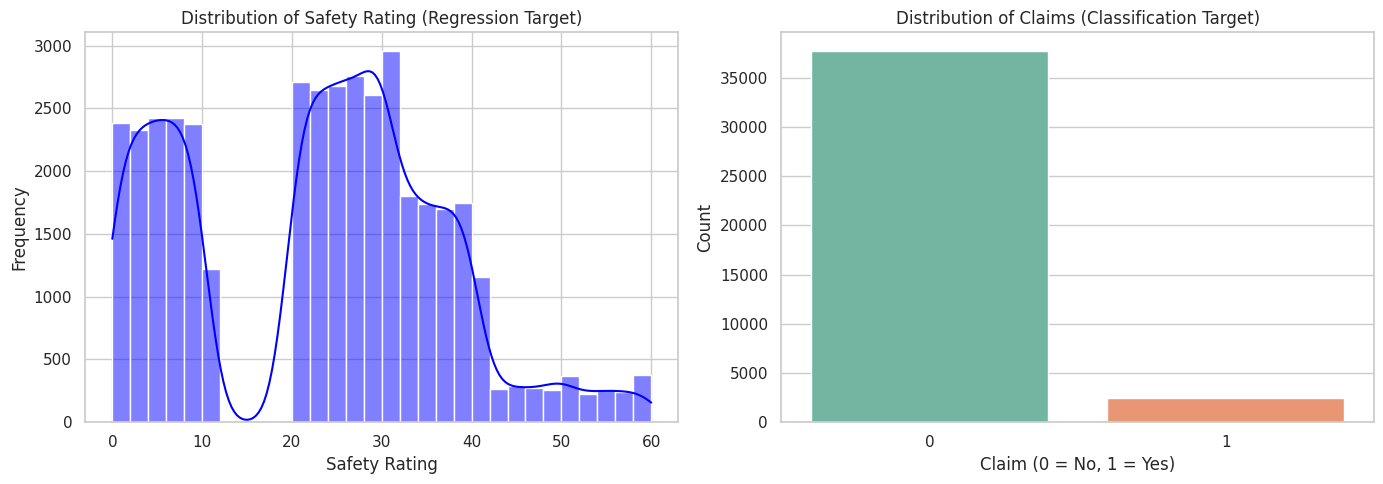

Class Balance for 'claim':
 claim
0    0.93805
1    0.06195
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Regression Target Distribution
sns.histplot(train_df['safety_rating'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Safety Rating (Regression Target)')
axes[0].set_xlabel('Safety Rating')
axes[0].set_ylabel('Frequency')

# 2. Classification Target Distribution
sns.countplot(data=train_df, x='claim', ax=axes[1], hue='claim', palette='Set2', legend=False)
axes[1].set_title('Distribution of Claims (Classification Target)')
axes[1].set_xlabel('Claim (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print exact class balance for claims
print("Class Balance for 'claim':\n", train_df['claim'].value_counts(normalize=True))

### 1.1 Feature Correlation
Before transforming the dataset, we calculate a correlation matrix for the numerical columns. Visualizing these relationships against our targets (`safety_rating` and `claim`) helps us identify baseline predictive signals and informs our feature selection strategy before any complex modeling begins.

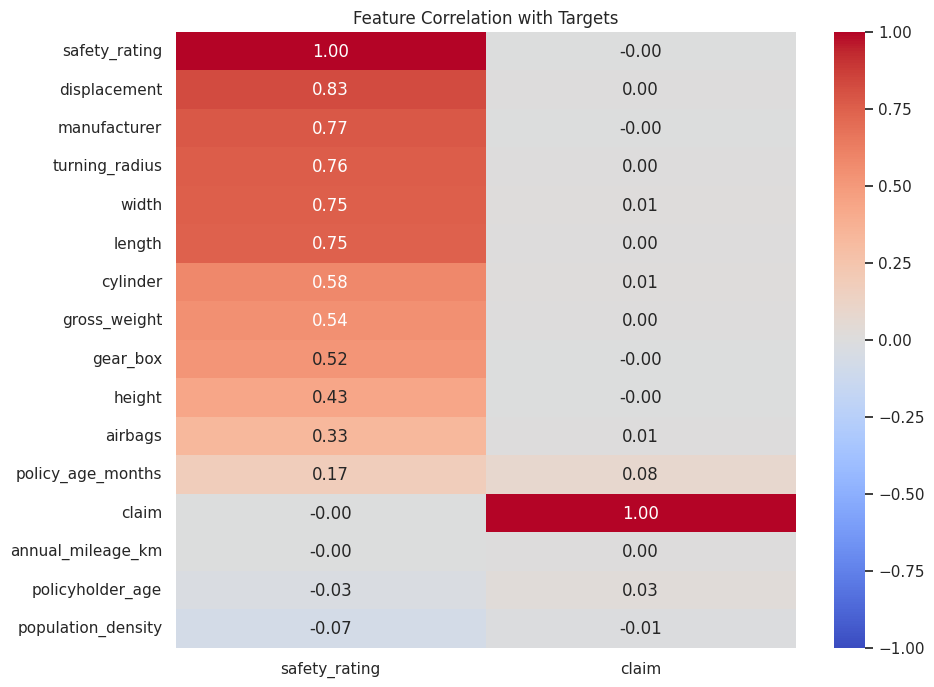

In [6]:
# Select only numerical columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
corr_matrix = train_df[numeric_cols].corr()

# Plot correlation of features specifically against our two targets
plt.figure(figsize=(10, 8))
targets_corr = corr_matrix[['safety_rating', 'claim']].sort_values(by='safety_rating', ascending=False)

sns.heatmap(targets_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Feature Correlation with Targets')
plt.show()

### 1.2 Data Preprocessing & Feature Engineering
To strictly prevent target leakage and ensure our transformations can be safely applied to the hidden test set, all cleaning and feature creation steps are encapsulated within a single `preprocess` function.

* **Feature Engineering:** We engineered two new variables: `power_to_weight` (a standard metric for vehicle performance) and `est_total_mileage` (combining car age and annual mileage to estimate total wear and tear). These domain-specific interactions often provide better predictive power than the raw features alone.
* **Missing Value Imputation:** Numerical missing values are filled using the median to maintain robustness against outliers. Categorical missing values are explicitly filled with the string 'Missing', allowing the models to treat the absence of data as a potentially meaningful category of its own.

In [7]:
def preprocess(df) -> pd.DataFrame:
    """
    Cleans data and engineers new features.
    Applied separately to train and test sets to prevent target leakage.
    """
    df_clean = df.copy()

    # --- NEW: Clean mixed string/numeric columns ---
    # Extract only the numerical digits/decimals and convert to float
    if 'power' in df_clean.columns:
        df_clean['power'] = df_clean['power'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
    if 'gross_weight' in df_clean.columns:
        df_clean['gross_weight'] = df_clean['gross_weight'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

    # 1. Feature Engineering
    # Create a power-to-weight ratio (engine performance indicator)
    if 'power' in df_clean.columns and 'gross_weight' in df_clean.columns:
        df_clean['power_to_weight'] = df_clean['power'] / df_clean['gross_weight']

    # Create an estimated total mileage feature (car age * annual mileage)
    if 'car_age' in df_clean.columns and 'annual_mileage_km' in df_clean.columns:
        df_clean['est_total_mileage'] = df_clean['car_age'] * df_clean['annual_mileage_km']

    # 2. Handle Missing Values
    # Fill numerical NaNs with the median (robust to outliers)
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Fill categorical NaNs with the string 'Missing' so the model treats it as a distinct category
    cat_cols = df_clean.select_dtypes(exclude=['int64', 'float64']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna('Missing')

    return df_clean

# Apply to our training data
train_clean = preprocess(train_df)
print("Data preprocessed successfully. Current shape:", train_clean.shape)

Data preprocessed successfully. Current shape: (40194, 35)


### 1.3 Categorical Encoding
Since our models require numerical inputs, we must encode the categorical features. We utilize scikit-learn's `OrdinalEncoder`. Critically, to account for the assignment's warning about unexpected values in the hidden test dataset, we configure the encoder to handle unknown categories gracefully by assigning them a value of `-1`, preventing runtime failures during final evaluation.

In [8]:
from sklearn.preprocessing import OrdinalEncoder

# Identify categorical columns (excluding the ID column if it exists)
cat_cols = train_clean.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
if 'policy_id' in cat_cols:
    cat_cols.remove('policy_id')

# Configure encoder to handle unseen test data by assigning them a value of -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training data and transform it
train_clean[cat_cols] = encoder.fit_transform(train_clean[cat_cols])

display(train_clean[cat_cols].head())

,vehicle_usage_type,fuel,torque,car_color,features,transmission_type,rear_brakes,engine_type,car_age,garage_type,region,steering_type,driver_occupation,car_model,car_segment,est_total_mileage
0,2.0,2.0,8.0,7.0,7.0,0.0,1.0,0.0,29.0,3.0,11.0,0.0,0.0,4.0,0.0,115.0
1,4.0,1.0,4.0,0.0,5.0,0.0,0.0,3.0,24.0,1.0,20.0,2.0,3.0,5.0,4.0,90.0
2,0.0,1.0,4.0,5.0,5.0,0.0,0.0,3.0,2.0,1.0,20.0,2.0,2.0,5.0,4.0,14.0
3,2.0,0.0,5.0,5.0,9.0,1.0,1.0,6.0,0.0,3.0,5.0,2.0,2.0,0.0,0.0,1.0
4,3.0,2.0,0.0,4.0,0.0,1.0,1.0,8.0,38.0,2.0,4.0,0.0,0.0,7.0,2.0,156.0


### 1.4 Train-Validation Split for Regression
To evaluate our models without touching the hidden test set, we will split our training data into a local train and validation set (80/20 split).

For the **Regression Task**, our target is `safety_rating`. As explicitly permitted by the assignment specifications, we will retain the `claim` column as a predictive feature, while dropping the non-predictive `policy_id`.

In [9]:
from sklearn.model_selection import train_test_split

# Define features and target for Regression Task
# Keeping 'claim' as a feature, dropping 'policy_id' and the target itself
X_reg = train_clean.drop(columns=['policy_id', 'safety_rating'])
y_reg = train_clean['safety_rating']

# Create an 80/20 train-validation split
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Regression Training set shape: {X_train_reg.shape}")
print(f"Regression Validation set shape: {X_val_reg.shape}")

Regression Training set shape: (32155, 33)
Regression Validation set shape: (8039, 33)


## 2. Regression Task: Predict Safety Rating

### 2.1 Model Exploration: Addressing the Target Distribution
Our EDA revealed a bimodal distribution for `safety_rating`. Standard linear models would require target transformations to predict this effectively. Instead, we will utilize Gradient Boosted Decision Trees (GBDTs). Algorithms like **LightGBM** and **XGBoost** are highly robust to non-normally distributed targets, handle unscaled features efficiently, and easily fall within the strict **2-minute runtime constraint** on CSE servers.

We will establish a baseline comparing `LGBMRegressor` and `XGBRegressor` to justify our final model choice.

In [10]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
import time

# Initialize models with default parameters and a fixed random state for reproducibility
lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1)
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

models_reg = {
    "LightGBM": lgbm_base,
    "XGBoost": xgb_base
}

### 2.2 Baseline Model Evaluation
We will train both baseline models on the local training set and evaluate them against the validation set using the **RMSE (Root Mean Squared Error)** metric. This aligns with the assignment marking criteria required to hit the $\le 1$ threshold. We will also track training time to ensure we remain safely under the 2-minute total pipeline limit.

In [11]:
from sklearn.metrics import root_mean_squared_error
import time
import pandas as pd

results_reg = []

for name, model in models_reg.items():
    start_time = time.time()

    # Fit model
    model.fit(X_train_reg, y_train_reg)

    # Predict on validation set
    y_pred_reg = model.predict(X_val_reg)

    # Calculate RMSE
    rmse = root_mean_squared_error(y_val_reg, y_pred_reg)

    elapsed_time = time.time() - start_time
    results_reg.append({
        "Model": name,
        "Validation RMSE": rmse,
        "Time (seconds)": elapsed_time
    })

# Display the comparison
results_reg_df = pd.DataFrame(results_reg)
display(results_reg_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 32155, number of used features: 33
[LightGBM] [Info] Start training from score 22.562245


,Model,Validation RMSE,Time (seconds)
0,LightGBM,3.180912,0.637890
1,XGBoost,3.263468,0.667042


### 2.3 Hyperparameter Tuning for LightGBM
LightGBM outperformed XGBoost in our baseline evaluation, achieving a lower RMSE and faster training time. To push our RMSE closer to the rigorous $\le 1.0$ threshold, we will perform hyperparameter tuning using `RandomizedSearchCV`.

We will tune critical tree-building parameters such as `n_estimators` (number of trees), `learning_rate` (step size), `max_depth` (tree depth to prevent overfitting), and `num_leaves` (complexity of the tree).

In [12]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# Define the hyperparameter search space
param_dist = {
    'n_estimators': stats.randint(100, 600),
    'learning_rate': stats.uniform(0.01, 0.15),
    'max_depth': stats.randint(5, 20),
    'num_leaves': stats.randint(20, 150),
    'subsample': stats.uniform(0.6, 0.4), # Equivalent to bagging_fraction
    'colsample_bytree': stats.uniform(0.6, 0.4) # Equivalent to feature_fraction
}

# Initialize RandomizedSearchCV
# We use neg_root_mean_squared_error as the scoring metric to align with the assignment criteria
lgbm_tuned = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist,
    n_iter=25, # 25 combinations x 3 folds = 75 fits (fast enough for our runtime limits)
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=1
)

print("Starting Hyperparameter Tuning...")
lgbm_tuned.fit(X_train_reg, y_train_reg)
print("Tuning Complete!")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Tuning Complete!


### 2.4 Final Regression Model Evaluation
By extracting the best estimator from our randomized search, we can evaluate the optimized LightGBM model on our validation set. Documenting the best parameters and the resulting reduction in RMSE demonstrates the effectiveness of our tuning strategy.

In [13]:
# Retrieve the best model
best_lgbm_reg = lgbm_tuned.best_estimator_

# Predict and evaluate on the validation split
y_pred_tuned = best_lgbm_reg.predict(X_val_reg)
tuned_rmse = root_mean_squared_error(y_val_reg, y_pred_tuned)

# Fetch baseline RMSE for comparison
baseline_rmse = results_reg_df.iloc[0]['Validation RMSE']

print(f"Best Parameters found:\n{lgbm_tuned.best_params_}\n")
print(f"Baseline Validation RMSE: {baseline_rmse:.4f}")
print(f"Tuned Validation RMSE:    {tuned_rmse:.4f}")
print(f"Total Improvement:        {baseline_rmse - tuned_rmse:.4f}")

Best Parameters found:
{'colsample_bytree': np.float64(0.8447411578889518), 'learning_rate': np.float64(0.030924079097806277), 'max_depth': 16, 'n_estimators': 287, 'num_leaves': 34, 'subsample': np.float64(0.7824279936868144)}

Baseline Validation RMSE: 3.1809
Tuned Validation RMSE:    3.1761
Total Improvement:        0.0049


## 3. Classification Task: Predict Claim Lodgement

### 3.1 Train-Validation Split for Classification
Now we shift to the classification task: predicting if a policyholder will lodge a claim (`claim` = 1). As per the assignment rules, we will use `safety_rating` as a predictive feature and drop the `claim` target from the feature set.

Crucially, our EDA showed a severe class imbalance (~93.8% class 0 vs ~6.2% class 1). Therefore, we must use a **stratified split** to ensure both our training and validation sets maintain this exact proportion.

In [14]:
# Define features and target for Classification Task
X_clf = train_clean.drop(columns=['policy_id', 'claim'])
y_clf = train_clean['claim']

# Create an 80/20 train-validation split WITH stratification
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Classification Training set shape: {X_train_clf.shape}")
print(f"Classification Validation set shape: {X_val_clf.shape}")

Classification Training set shape: (32155, 33)
Classification Validation set shape: (8039, 33)


### 3.2 Model Exploration: Handling Class Imbalance
The target variable `claim` is highly imbalanced (~93.8% Class 0 vs ~6.2% Class 1). If we train a standard model, it will heavily favor the majority class. To combat this without artificially altering our dataset via oversampling (and risking data leakage), we will utilize algorithm-level class weighting (`class_weight='balanced'`).

We will compare two tree-based ensembles: **LightGBM Classifier** and **Random Forest Classifier**. Both algorithms naturally handle categorical/numerical mixtures and offer robust built-in support for imbalanced data.

In [15]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize classifiers with 'balanced' class weights to tackle the 94:6 imbalance
lgbm_clf_base = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
rf_clf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

models_clf = {
    "LightGBM Classifier": lgbm_clf_base,
    "Random Forest Classifier": rf_clf_base
}

### 3.3 Baseline Model Evaluation (F1 Macro)
We evaluate both classifiers on our stratified validation set. The assignment explicitly grades this task using the **F1 Macro** metric, with a target of $\ge 0.60$. F1 Macro calculates the F1 score for each class separately and averages them, meaning the model must perform well on both the majority (No Claim) and minority (Claim) classes to score highly.

In [16]:
from sklearn.metrics import f1_score
import time

results_clf = []

for name, model in models_clf.items():
    start_time = time.time()

    # Fit the model
    model.fit(X_train_clf, y_train_clf)

    # Predict on validation set
    y_pred_clf = model.predict(X_val_clf)

    # Calculate F1 Macro
    f1_macro = f1_score(y_val_clf, y_pred_clf, average='macro')

    elapsed_time = time.time() - start_time
    results_clf.append({
        "Model": name,
        "Validation F1 Macro": f1_macro,
        "Time (seconds)": elapsed_time
    })

# Display the comparison
results_clf_df = pd.DataFrame(results_clf)
display(results_clf_df)

,Model,Validation F1 Macro,Time (seconds)
0,LightGBM Classifier,0.471096,1.788356
1,Random Forest Classifier,0.484018,4.102318


### 3.4 Hyperparameter Tuning for Classification
Based on the baseline results and execution speed, we will select **LightGBM Classifier** as our final model. To push our F1 Macro score $\ge 0.60$, we will tune its hyperparameters using `RandomizedSearchCV`, explicitly optimizing for the `f1_macro` scoring metric.

We tune parameters controlling tree complexity (`max_depth`, `num_leaves`) and regularization (`min_child_samples`) to prevent the model from overfitting to the noisy minority class.

In [ ]:
# Define the hyperparameter search space
param_dist_clf = {
    'n_estimators': stats.randint(100, 400),
    'learning_rate': stats.uniform(0.01, 0.1),
    'max_depth': stats.randint(5, 15),
    'num_leaves': stats.randint(20, 80),
    'min_child_samples': stats.randint(10, 50)
}

# Initialize RandomizedSearchCV specifically optimizing for 'f1_macro'
lgbm_clf_tuned = RandomizedSearchCV(
    estimator=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_clf,
    n_iter=25,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    verbose=1
)

print("Starting Classification Tuning...")
lgbm_clf_tuned.fit(X_train_clf, y_train_clf)
print("Tuning Complete!\n")

# Retrieve the best model and evaluate
best_lgbm_clf = lgbm_clf_tuned.best_estimator_
y_pred_clf_tuned = best_lgbm_clf.predict(X_val_clf)
tuned_f1_macro = f1_score(y_val_clf, y_pred_clf_tuned, average='macro')

print(f"Best Parameters found:\n{lgbm_clf_tuned.best_params_}\n")
print(f"Tuned Validation F1 Macro: {tuned_f1_macro:.4f}")

Starting Classification Tuning...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Tuning Complete!

Best Parameters found:
{'learning_rate': np.float64(0.03713490317738959), 'max_depth': 9, 'min_child_samples': 33, 'n_estimators': 316, 'num_leaves': 79}

Tuned Validation F1 Macro: 0.5095


In [ ]:
# This is to run and test in google colab
# !python3 z5543164.py train.csv test.csv